In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Compare different learning objectives

## In/Excluding penalty_e 
- v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneTrue
- v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse

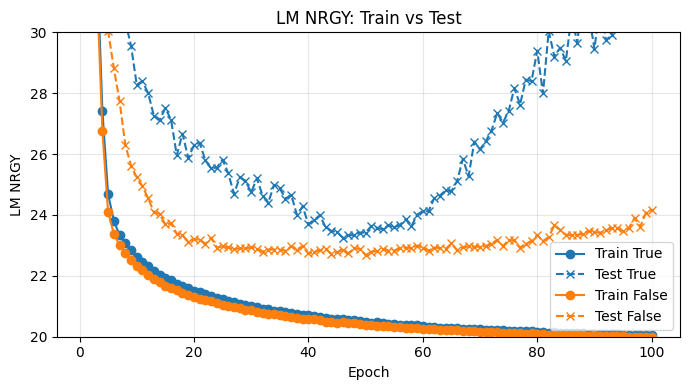

1      53.5417
3      44.8615
5      32.5607
7      30.7107
9      33.0889
        ...   
191    31.3888
193    31.6885
195    32.3665
197    32.7449
199    32.5639
Name: LM NRGY, Length: 100, dtype: float64
1      54.8698
3      45.5901
5      33.7839
7      30.2860
9      30.0410
        ...   
191    23.5580
193    23.9024
195    23.6144
197    24.0793
199    24.1662
Name: LM NRGY, Length: 100, dtype: float64


In [2]:
# --- load the txt file (adjust path) ---
path_true = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneTrue/log.txt"
path_false = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05_peneFalse/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df_true = pd.read_csv(path_true, skipinitialspace=True)
df_false = pd.read_csv(path_false, skipinitialspace=True)

# clean column names (strip spaces)
df_true.columns = [c.strip() for c in df_true.columns]
df_false.columns = [c.strip() for c in df_false.columns]


# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m_true = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_true["split"] = m_true[0]
df_true["epoch"] = m_true[1].astype(int)

m_false = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_false["split"] = m_false[0]
df_false["epoch"] = m_false[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df_true.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train_true = df_true[df_true["split"] == "Train"].sort_values("epoch")
test_true  = df_true[df_true["split"] == "Test"].sort_values("epoch")

train_false = df_false[df_false["split"] == "Train"].sort_values("epoch")
test_false  = df_false[df_false["split"] == "Test"].sort_values("epoch")

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train_true["epoch"], train_true[col], marker="o", label="Train True", color = "tab:blue")
plt.plot(test_true["epoch"],  test_true[col],  marker="x", label="Test True", color = "tab:blue", linestyle="--")

plt.plot(train_false["epoch"], train_false[col], marker="o", label="Train False", color = "tab:orange")
plt.plot(test_false["epoch"],  test_false[col],  marker="x", label="Test False", color = "tab:orange", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
plt.ylim(20,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test_true[col])
print(test_false[col])

## Alternate training of both models or not

# Compare different models

## v5_model/_100_4_100_100_1001_100_2_100_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05

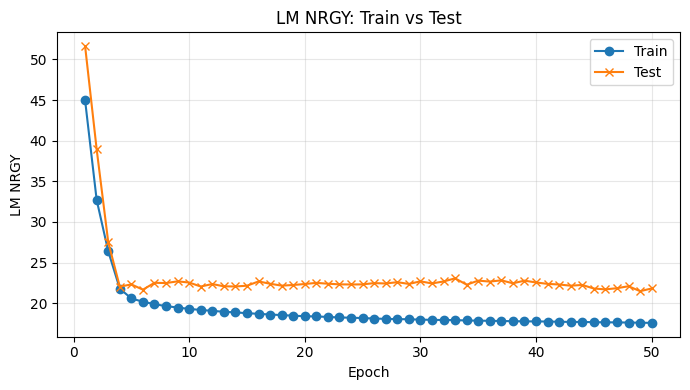

1     51.6275
3     38.9362
5     27.5216
7     22.0401
9     22.3170
11    21.6709
13    22.5136
15    22.4832
17    22.6933
19    22.5447
21    22.0581
23    22.3616
25    22.0827
27    22.0618
29    22.1566
31    22.6818
33    22.4002
35    22.1647
37    22.2456
39    22.3659
41    22.5074
43    22.4028
45    22.3231
47    22.3089
49    22.3195
51    22.4779
53    22.4305
55    22.5917
57    22.3762
59    22.6927
61    22.4359
63    22.6775
65    23.0639
67    22.2795
69    22.7830
71    22.6643
73    22.8162
75    22.4541
77    22.7806
79    22.5553
81    22.3826
83    22.3039
85    22.1598
87    22.2488
89    21.8089
91    21.7049
93    21.8516
95    22.0917
97    21.4856
99    21.8164
Name: LM NRGY, dtype: float64


In [9]:

# --- load the txt file (adjust path) ---
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_100_4_100_100_1001_100_2_100_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
#plt.ylim(15,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])

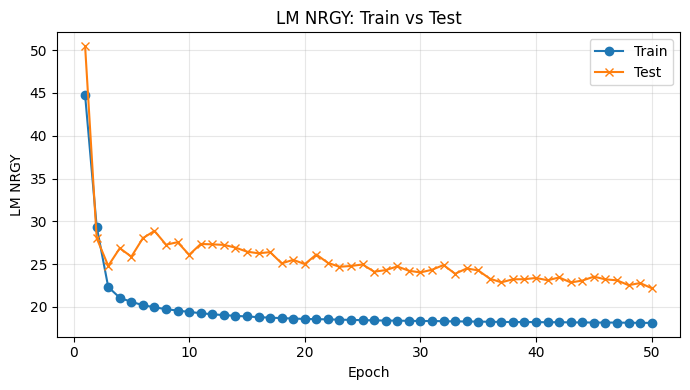

1     50.4750
3     28.0343
5     24.7910
7     26.8579
9     25.8621
11    28.0324
13    28.8773
15    27.2611
17    27.5564
19    26.0804
21    27.3485
23    27.3045
25    27.2410
27    26.9248
29    26.4485
31    26.2587
33    26.3956
35    25.0822
37    25.4915
39    24.9960
41    26.1151
43    25.1365
45    24.6812
47    24.7778
49    24.9494
51    24.1052
53    24.2942
55    24.7222
57    24.2172
59    24.0183
61    24.3346
63    24.8819
65    23.8648
67    24.4856
69    24.2583
71    23.2925
73    22.8622
75    23.2197
77    23.2261
79    23.3770
81    23.1050
83    23.4326
85    22.8508
87    23.0659
89    23.5269
91    23.2101
93    23.0981
95    22.5327
97    22.7796
99    22.1783
Name: LM NRGY, dtype: float64


In [10]:
# --- load the txt file (adjust path) ---
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr0.0001/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
#plt.ylim(15,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])

## v5_model/_50_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr5e-05

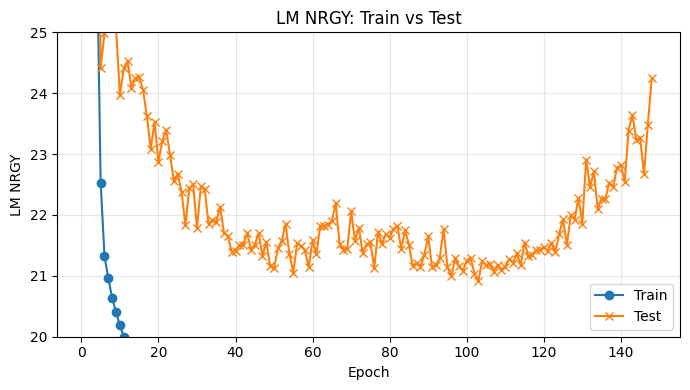

1      51.7337
3      54.6264
5      47.0155
7      30.5011
9      24.4178
        ...   
287    23.2357
289    23.2693
291    22.6762
293    23.4735
295    24.2455
Name: LM NRGY, Length: 148, dtype: float64


In [11]:
# --- load the txt file (adjust path) ---
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisTrue_lr5e-05/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
plt.ylim(20,25)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])

LM s1 1      69.0933
3      81.4125
5      75.0887
7      55.5300
9      46.4709
        ...   
287    40.3671
289    40.2951
291    39.9530
293    40.6241
295    41.3842
Name: LM s1, Length: 148, dtype: float64
LM s2 1      34.7192
3      53.5724
5      56.1465
7      50.0578
9      44.1061
        ...   
287    34.2628
289    34.0517
291    34.5538
293    34.3012
295    34.2773
Name: LM s2, Length: 148, dtype: float64


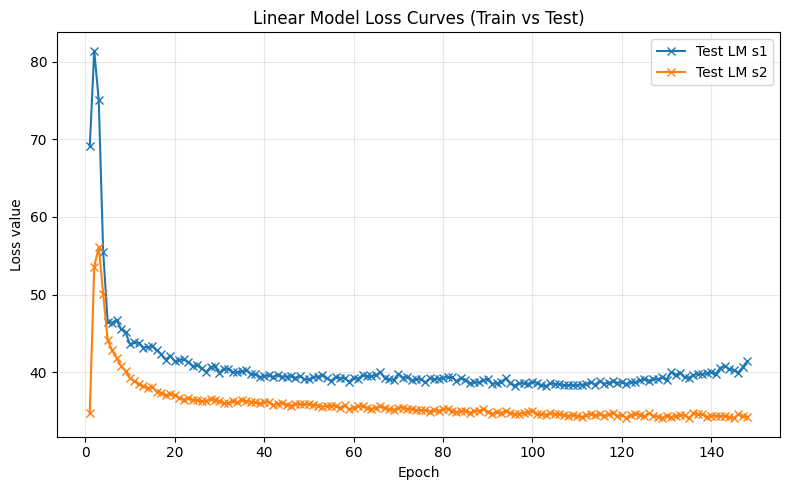

In [12]:
# --- load the txt file ---
df = pd.read_csv(path, skipinitialspace=True)

# clean column names
df.columns = [c.strip() for c in df.columns]

# split Epoch column into Train/Test + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# separate train and test
train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")

# --- columns to plot ---
lm_cols = ["LM s1", "LM s2"]

# --- plot each metric ---
plt.figure(figsize=(8, 5))

for col in lm_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in file!")

    #plt.plot(train["epoch"], train[col], marker="x", label=f"Train {col}")
    plt.plot(test["epoch"],  test[col],  marker="x", linestyle="-", label=f"Test {col}")
    print(col, test[col])
# formatting
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Linear Model Loss Curves (Train vs Test)")
#plt.ylim(35,45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05

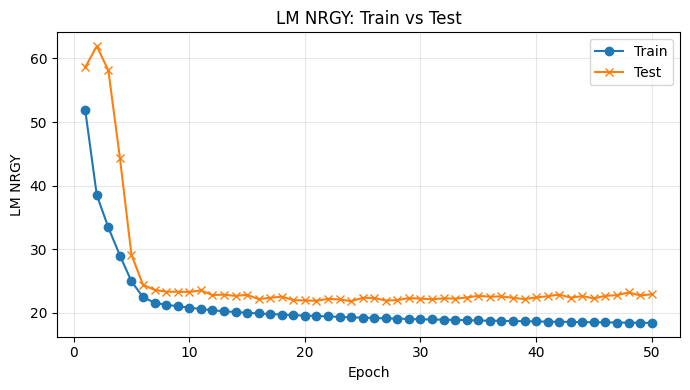

1     58.6047
3     61.9266
5     58.1161
7     44.3696
9     29.1254
11    24.4086
13    23.6103
15    23.3269
17    23.3129
19    23.2930
21    23.5186
23    22.7952
25    22.8703
27    22.6573
29    22.8388
31    22.1640
33    22.3632
35    22.5535
37    22.0038
39    21.9490
41    21.8964
43    22.1969
45    22.1029
47    21.8338
49    22.3554
51    22.3471
53    21.9260
55    22.0059
57    22.3236
59    22.2277
61    22.1319
63    22.2833
65    22.2347
67    22.4070
69    22.6853
71    22.5317
73    22.5922
75    22.3572
77    22.1664
79    22.4191
81    22.6131
83    22.8722
85    22.3837
87    22.6336
89    22.2725
91    22.6828
93    22.7760
95    23.2165
97    22.7410
99    22.9161
Name: LM NRGY, dtype: float64


In [56]:
# --- load the txt file (adjust path) ---
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
#plt.ylim(15,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])

## /v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue

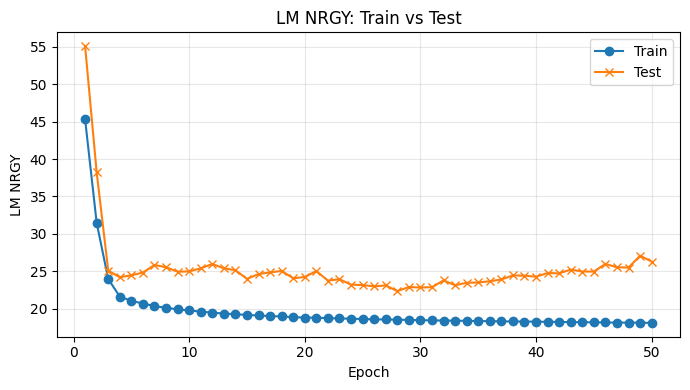

1     55.0557
3     38.2269
5     25.1090
7     24.2317
9     24.4827
11    24.8540
13    25.8646
15    25.5589
17    24.9646
19    25.0072
21    25.4197
23    25.9956
25    25.4190
27    25.1673
29    24.0094
31    24.6542
33    24.8750
35    25.0685
37    24.0851
39    24.2651
41    25.0535
43    23.7704
45    23.9660
47    23.2388
49    23.1839
51    23.0072
53    23.1361
55    22.3811
57    22.9167
59    22.8595
61    22.9011
63    23.8048
65    23.1597
67    23.4855
69    23.5300
71    23.6912
73    23.9310
75    24.4704
77    24.4371
79    24.2950
81    24.7946
83    24.7365
85    25.2486
87    24.9909
89    24.9838
91    26.0020
93    25.5559
95    25.5222
97    27.1051
99    26.3131
Name: LM NRGY, dtype: float64
LM s1 1     83.5118
3     65.4443
5     47.5156
7     45.7653
9     45.0144
11    45.0001
13    45.9805
15    45.1415
17    44.3244
19    44.3952
21    44.7381
23    45.3671
25    44.6950
27    44.3816
29    43.1457
31    43.7105
33    43.7862
35    43.9620
37    42.950

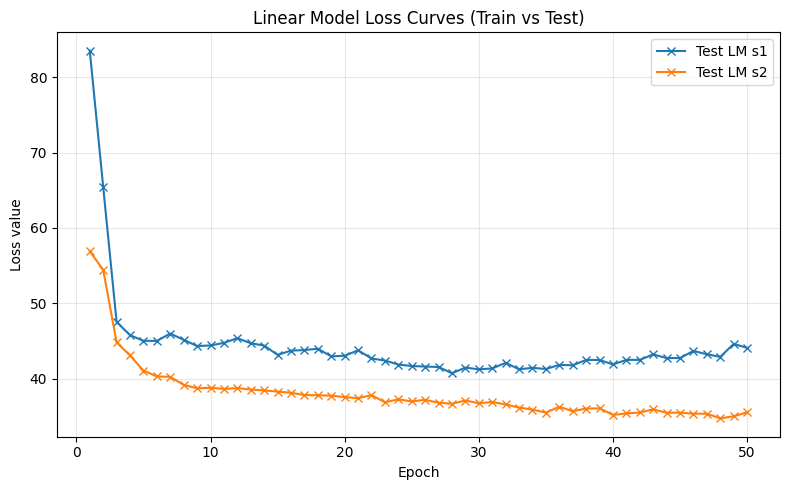

In [15]:
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue/log.txt"
# --- load the txt file ---
df = pd.read_csv(path, skipinitialspace=True)

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
#plt.ylim(15,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])
###
# clean column names
df.columns = [c.strip() for c in df.columns]

# split Epoch column into Train/Test + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# separate train and test
train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")

# --- columns to plot ---
lm_cols = ["LM s1", "LM s2"]

# --- plot each metric ---
plt.figure(figsize=(8, 5))

for col in lm_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in file!")

    #plt.plot(train["epoch"], train[col], marker="x", label=f"Train {col}")
    plt.plot(test["epoch"],  test[col],  marker="x", linestyle="-", label=f"Test {col}")
    print(col, test[col])
# formatting
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Linear Model Loss Curves (Train vs Test)")
#plt.ylim(35,45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## /v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05

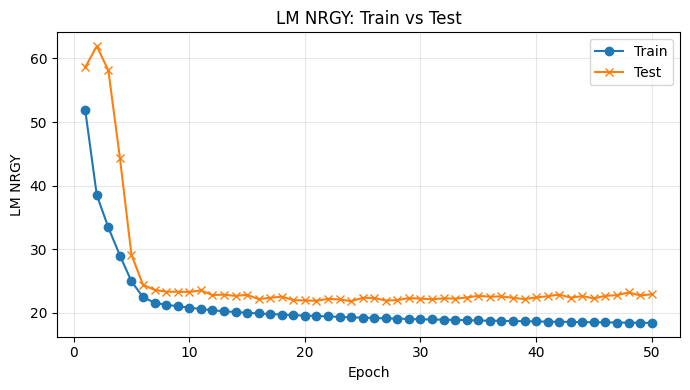

1     58.6047
3     61.9266
5     58.1161
7     44.3696
9     29.1254
11    24.4086
13    23.6103
15    23.3269
17    23.3129
19    23.2930
21    23.5186
23    22.7952
25    22.8703
27    22.6573
29    22.8388
31    22.1640
33    22.3632
35    22.5535
37    22.0038
39    21.9490
41    21.8964
43    22.1969
45    22.1029
47    21.8338
49    22.3554
51    22.3471
53    21.9260
55    22.0059
57    22.3236
59    22.2277
61    22.1319
63    22.2833
65    22.2347
67    22.4070
69    22.6853
71    22.5317
73    22.5922
75    22.3572
77    22.1664
79    22.4191
81    22.6131
83    22.8722
85    22.3837
87    22.6336
89    22.2725
91    22.6828
93    22.7760
95    23.2165
97    22.7410
99    22.9161
Name: LM NRGY, dtype: float64
LM s1 1     76.7202
3     90.0821
5     86.6144
7     70.3321
9     51.8618
11    45.6182
13    44.3406
15    43.6155
17    43.5716
19    43.2861
21    43.4861
23    42.6092
25    42.5689
27    42.3077
29    42.2904
31    41.6004
33    42.0164
35    41.9730
37    41.433

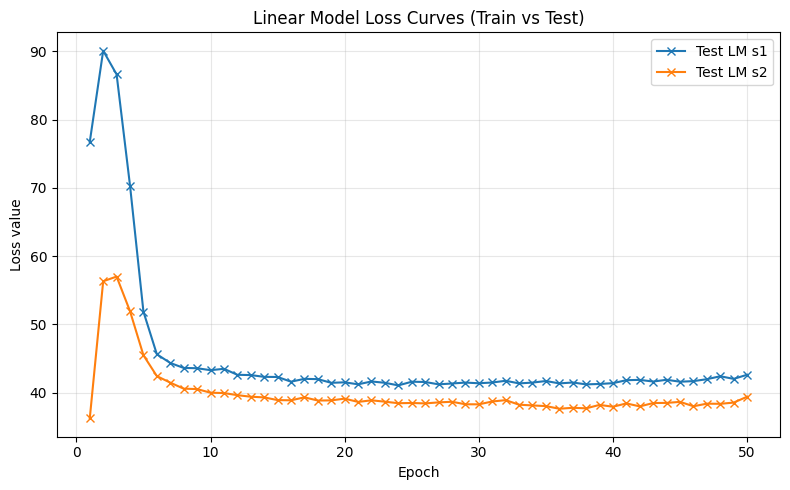

In [16]:
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05/log.txt"
# --- load the txt file ---
df = pd.read_csv(path, skipinitialspace=True)

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
#plt.ylim(15,30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test[col])
###
# clean column names
df.columns = [c.strip() for c in df.columns]

# split Epoch column into Train/Test + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# separate train and test
train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")

# --- columns to plot ---
lm_cols = ["LM s1", "LM s2"]

# --- plot each metric ---
plt.figure(figsize=(8, 5))

for col in lm_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in file!")

    #plt.plot(train["epoch"], train[col], marker="x", label=f"Train {col}")
    plt.plot(test["epoch"],  test[col],  marker="x", linestyle="-", label=f"Test {col}")
    print(col, test[col])
# formatting
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Linear Model Loss Curves (Train vs Test)")
#plt.ylim(35,45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## /v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_50epochs

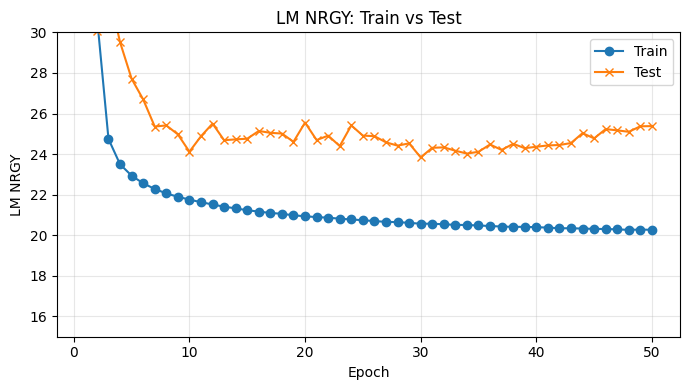

1     45.4957
3     30.0755
5     32.0578
7     29.5163
9     27.7136
11    26.6944
13    25.3572
15    25.4128
17    24.9725
19    24.1183
21    24.8788
23    25.5027
25    24.6848
27    24.7249
29    24.7585
31    25.1393
33    25.0483
35    25.0123
37    24.6046
39    25.5526
41    24.6915
43    24.9093
45    24.3962
47    25.4131
49    24.9104
51    24.8837
53    24.5791
55    24.4168
57    24.5280
59    23.8387
61    24.3095
63    24.3321
65    24.1657
67    24.0254
69    24.1130
71    24.4731
73    24.2049
75    24.5066
77    24.2908
79    24.3612
81    24.4268
83    24.4481
85    24.5440
87    25.0307
89    24.7748
91    25.2313
93    25.1695
95    25.0983
97    25.3701
99    25.3786
Name: LM NRGY, dtype: float64
LM s1 1     75.7433
3     56.8499
5     55.3692
7     51.7733
9     49.3575
11    48.0800
13    46.6630
15    46.5385
17    46.0266
19    45.0908
21    45.7384
23    46.7343
25    45.6806
27    45.7962
29    45.8969
31    45.8705
33    45.9172
35    46.0333
37    45.440

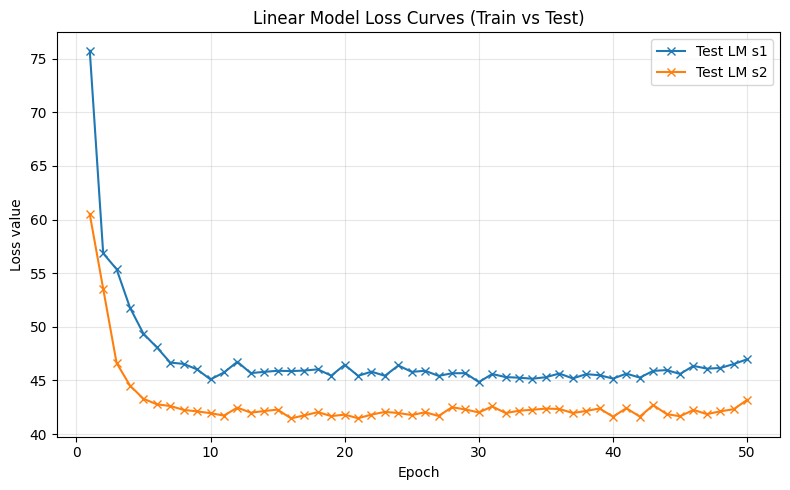

In [55]:
path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_50epochs/log.txt"
# --- load the txt file ---
df = pd.read_csv(path, skipinitialspace=True)

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(15,30)
#plt.xlim(0,40)
plt.show()
print(test[col])
###
# clean column names
df.columns = [c.strip() for c in df.columns]

# split Epoch column into Train/Test + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# separate train and test
train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")

# --- columns to plot ---
lm_cols = ["LM s1", "LM s2"]

# --- plot each metric ---
plt.figure(figsize=(8, 5))

for col in lm_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in file!")

    #plt.plot(train["epoch"], train[col], marker="x", label=f"Train {col}")
    plt.plot(test["epoch"],  test[col],  marker="x", linestyle="-", label=f"Test {col}")
    print(col, test[col])
# formatting
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Linear Model Loss Curves (Train vs Test)")
#plt.ylim(35,45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## /v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05

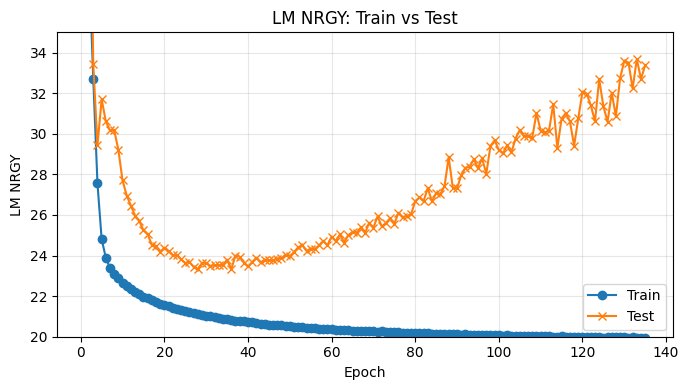

1      54.2719
3      45.8413
5      33.4343
7      29.4289
9      31.6972
        ...   
261    33.5124
263    32.2391
265    33.6742
267    32.7042
269    33.3814
Name: LM NRGY, Length: 135, dtype: float64
LM s1 1      75.1065
3      77.9161
5      63.7931
7      55.5099
9      55.1424
        ...   
261    54.6817
263    53.4386
265    55.1762
267    53.9644
269    55.0108
Name: LM s1, Length: 135, dtype: float64
LM s2 1      41.6693
3      64.1496
5      60.7177
7      52.1619
9      46.8904
        ...   
261    42.3386
263    42.3990
265    43.0039
267    42.5203
269    43.2589
Name: LM s2, Length: 135, dtype: float64


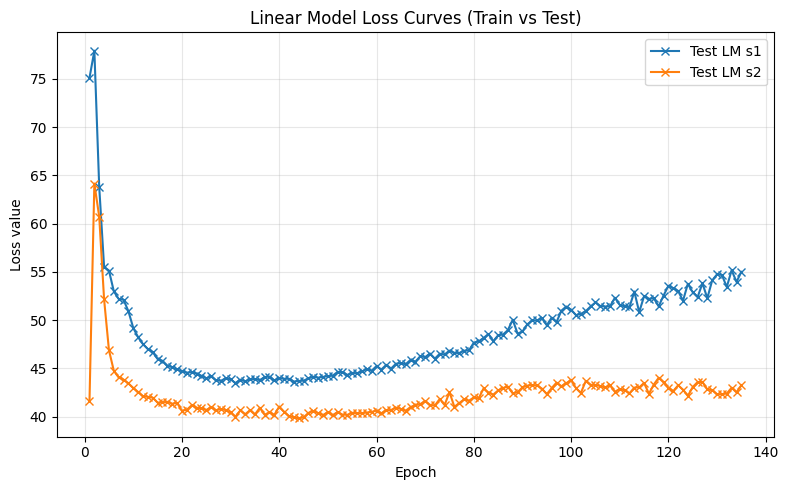

Test:       Epoch  Total loss  Total S1  Total S2  DPA NRGY   DPA s1   DPA s2  \
1    Test 1     85.3019  128.1822   85.7606   31.0300  53.0757  44.0913   
3    Test 2     74.5119  134.0182  119.0126   28.6706  56.1021  54.8630   
5    Test 3     58.3770  112.3956  108.0372   24.9427  48.6024  47.3195   
7    Test 4     54.1912   99.6182   90.8540   24.7622  44.1083  38.6921   
9    Test 5     56.7590   97.9869   82.4558   25.0619  42.8446  35.5654   
11   Test 6     53.5212   92.7881   78.5339   22.9080  39.7963  33.7766   
13   Test 7     51.8466   90.4758   77.2583   21.6767  38.2740  33.1944   
15   Test 8     51.8208   90.3658   77.0899   21.6327  38.2538  33.2422   
17   Test 9     50.1128   88.4753   76.7249   20.9105  37.5487  33.2764   
19  Test 10     46.7894   84.5261   75.4735   19.0872  35.3341  32.4937   
21  Test 11     45.8356   82.8405   74.0100   18.8818  34.6099  31.4561   
23  Test 12     45.2288   81.8694   73.2814   18.7753  34.3549  31.1592   
25  Test 13     45.

In [65]:
# /work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05

path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v6_model/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisTrue_lr5e-05/log.txt"
# --- load the txt file ---
df = pd.read_csv(path, skipinitialspace=True)

# read as CSV (comma-separated, with spaces after commas)
df = pd.read_csv(path, skipinitialspace=True)

# clean column names (strip spaces)
df.columns = [c.strip() for c in df.columns]

# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")


# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train["epoch"], train[col], marker="o", label="Train")
plt.plot(test["epoch"],  test[col],  marker="x", label="Test")
plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(20,35)
#plt.xlim(0,40)
plt.show()
print(test[col])
###
# clean column names
df.columns = [c.strip() for c in df.columns]

# split Epoch column into Train/Test + epoch number
m = df["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df["split"] = m[0]
df["epoch"] = m[1].astype(int)

# separate train and test
train = df[df["split"] == "Train"].sort_values("epoch")
test  = df[df["split"] == "Test"].sort_values("epoch")

# --- columns to plot ---
lm_cols = ["LM s1", "LM s2"]

# --- plot each metric ---
plt.figure(figsize=(8, 5))

for col in lm_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in file!")

    #plt.plot(train["epoch"], train[col], marker="x", label=f"Train {col}")
    plt.plot(test["epoch"],  test[col],  marker="x", linestyle="-", label=f"Test {col}")
    print(col, test[col])
# formatting
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Linear Model Loss Curves (Train vs Test)")
#plt.ylim(35,45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print("Test:", test[:30])


## llaae_new/DistributionalPrincipalAutoencoder/joint_training/v6_data_model5/_100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_peneFalse
## llaae_new/DistributionalPrincipalAutoencoder/joint_training/v6_data_model5/_100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr5e-05_peneFalse

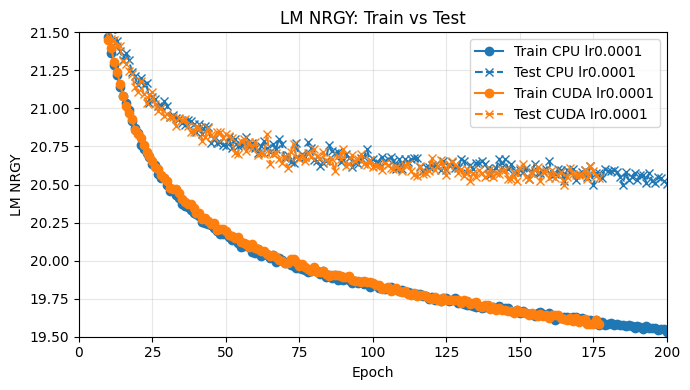

1      24.8765
3      23.3359
5      22.6993
7      22.3502
9      22.1007
        ...   
391    20.5131
393    20.5501
395    20.5423
397    20.5261
399    20.5042
Name: LM NRGY, Length: 200, dtype: float64
1      24.8144
3      23.2170
5      22.7338
7      22.3345
9      22.0995
        ...   
345    20.5389
347    20.6229
349    20.5921
351    20.5555
353    20.5399
Name: LM NRGY, Length: 177, dtype: float64


In [5]:
# --- load the txt file (adjust path) ---
path_true = "v6_data_model5/_devicecpu100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001/log.txt"
path_false = "v6_data_model5/_devicecuda100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df_true = pd.read_csv(path_true, skipinitialspace=True)
df_false = pd.read_csv(path_false, skipinitialspace=True)

# clean column names (strip spaces)
df_true.columns = [c.strip() for c in df_true.columns]
df_false.columns = [c.strip() for c in df_false.columns]


# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m_true = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_true["split"] = m_true[0]
df_true["epoch"] = m_true[1].astype(int)

m_false = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_false["split"] = m_false[0]
df_false["epoch"] = m_false[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df_true.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train_true = df_true[df_true["split"] == "Train"].sort_values("epoch")
test_true  = df_true[df_true["split"] == "Test"].sort_values("epoch")

train_false = df_false[df_false["split"] == "Train"].sort_values("epoch")
test_false  = df_false[df_false["split"] == "Test"].sort_values("epoch")

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train_true["epoch"], train_true[col], marker="o", label="Train CPU lr0.0001", color = "tab:blue")
plt.plot(test_true["epoch"],  test_true[col],  marker="x", label="Test CPU lr0.0001", color = "tab:blue", linestyle="--")

plt.plot(train_false["epoch"], train_false[col], marker="o", label="Train CUDA lr0.0001", color = "tab:orange")
plt.plot(test_false["epoch"],  test_false[col],  marker="x", label="Test CUDA lr0.0001", color = "tab:orange", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
plt.ylim(19.5,21.5)
plt.xlim(0,200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test_true[col])
print(test_false[col])

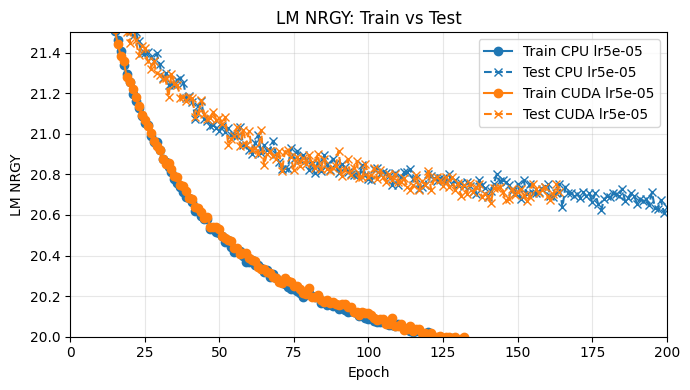

1      27.5400
3      24.3529
5      23.5000
7      23.0508
9      22.7088
        ...   
391    20.6339
393    20.6298
395    20.6743
397    20.6112
399    20.6409
Name: LM NRGY, Length: 200, dtype: float64
1      27.5852
3      24.2976
5      23.5486
7      23.0294
9      22.7167
        ...   
319    20.6942
321    20.6746
323    20.7018
325    20.7515
327    20.7139
Name: LM NRGY, Length: 164, dtype: float64


In [4]:
# --- load the txt file (adjust path) ---
path_true = "v6_data_model5/_devicecpu100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr5e-05/log.txt"
path_false = "v6_data_model5/_devicecuda100_6_100_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr5e-05/log.txt"

# read as CSV (comma-separated, with spaces after commas)
df_true = pd.read_csv(path_true, skipinitialspace=True)
df_false = pd.read_csv(path_false, skipinitialspace=True)

# clean column names (strip spaces)
df_true.columns = [c.strip() for c in df_true.columns]
df_false.columns = [c.strip() for c in df_false.columns]


# split "Epoch" like "Train 1" / "Test 1" into set + epoch number
m_true = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_true["split"] = m_true[0]
df_true["epoch"] = m_true[1].astype(int)

m_false = df_true["Epoch"].str.extract(r"^(Train|Test)\s+(\d+)$")
df_false["split"] = m_false[0]
df_false["epoch"] = m_false[1].astype(int)

# make sure the column name matches exactly
col = "LM NRGY"
if col not in df_true.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

train_true = df_true[df_true["split"] == "Train"].sort_values("epoch")
test_true  = df_true[df_true["split"] == "Test"].sort_values("epoch")

train_false = df_false[df_false["split"] == "Train"].sort_values("epoch")
test_false  = df_false[df_false["split"] == "Test"].sort_values("epoch")

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(train_true["epoch"], train_true[col], marker="o", label="Train CPU lr5e-05", color = "tab:blue")
plt.plot(test_true["epoch"],  test_true[col],  marker="x", label="Test CPU lr5e-05", color = "tab:blue", linestyle="--")

plt.plot(train_false["epoch"], train_false[col], marker="o", label="Train CUDA lr5e-05", color = "tab:orange")
plt.plot(test_false["epoch"],  test_false[col],  marker="x", label="Test CUDA lr5e-05", color = "tab:orange", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel(col)
plt.title("LM NRGY: Train vs Test")
plt.ylim(20,21.5)
plt.xlim(0,200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(test_true[col])
print(test_false[col])